In [67]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
import os
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Create outputs directory if it doesn't exist
output_dir = 'outputs'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created {output_dir} directory for saving plots")


In [69]:
# =============================================================================
#  DATA LOADING AND INITIAL EXPLORATION
# =============================================================================

# Load the dataset
df = pd.read_csv('GlobalWeatherRepository.csv')

print("Dataset Overview")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Display basic information
print("\nDataset Info:")
print(df.info())

print("\nFirst few rows:")
print(df.head())

print("\nSummary Statistics:")
print(df.describe())


Dataset Overview
Shape: (80866, 41)
Memory usage: 68.19 MB

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80866 entries, 0 to 80865
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       80866 non-null  object 
 1   location_name                 80866 non-null  object 
 2   latitude                      80866 non-null  float64
 3   longitude                     80866 non-null  float64
 4   timezone                      80866 non-null  object 
 5   last_updated_epoch            80866 non-null  int64  
 6   last_updated                  80866 non-null  object 
 7   temperature_celsius           80866 non-null  float64
 8   temperature_fahrenheit        80866 non-null  float64
 9   condition_text                80866 non-null  object 
 10  wind_mph                      80866 non-null  float64
 11  wind_kph                      80866 non-null 

In [71]:
# =============================================================================
#  DATA CLEANING AND PREPROCESSING
# =============================================================================

print("\n" + "="*50)
print("DATA CLEANING AND PREPROCESSING")
print("=" * 50)

# Check for missing values
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent
}).sort_values('Missing Percentage', ascending=False)

print("\nMissing Data Analysis:")
print(missing_df[missing_df['Missing Count'] > 0])

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

# Drop redundant temperature columns to avoid multicollinearity
redundant_cols = ['feels_like_celsius', 'temperature_fahrenheit', 'feels_like_fahrenheit']
df_cleaned = df.drop(columns=[col for col in redundant_cols if col in df.columns])
print(f"\nDropped redundant temperature columns: {[col for col in redundant_cols if col in df.columns]}")
print(f"Dataset shape after dropping redundant columns: {df_cleaned.shape}")

# Data type optimization and cleaning
# Convert categorical variables
categorical_cols = ['country', 'location_name', 'condition_text', 'wind_direction', 
                   'timezone', 'moon_phase']

# Handle time-based columns
df_cleaned['last_updated'] = pd.to_datetime(df_cleaned['last_updated'])
df_cleaned['hour'] = df_cleaned['last_updated'].dt.hour
df_cleaned['month'] = df_cleaned['last_updated'].dt.month

# Create derived features for analysis
df_cleaned['temp_range'] = df_cleaned['temperature_celsius'].max() - df_cleaned['temperature_celsius'].min()
df_cleaned['pressure_category'] = pd.cut(df_cleaned['pressure_mb'], 
                                bins=[0, 1000, 1020, float('inf')], 
                                labels=['Low', 'Normal', 'High'])
df_cleaned['humidity_category'] = pd.cut(df_cleaned['humidity'], 
                                bins=[0, 30, 70, 100], 
                                labels=['Dry', 'Moderate', 'Humid'])

# Update the main dataframe
df = df_cleaned.copy()

print("\nData cleaning completed. New features created:")
print("- hour: Hour of the day from last_updated")
print("- month: Month from last_updated") 
print("- temp_range: Temperature range")
print("- pressure_category: Categorized pressure levels")
print("- humidity_category: Categorized humidity levels")
print(f"\nFinal dataset shape: {df.shape}")


DATA CLEANING AND PREPROCESSING

Missing Data Analysis:
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []

Duplicate rows: 0

Dropped redundant temperature columns: ['feels_like_celsius', 'temperature_fahrenheit', 'feels_like_fahrenheit']
Dataset shape after dropping redundant columns: (80866, 38)

Data cleaning completed. New features created:
- hour: Hour of the day from last_updated
- month: Month from last_updated
- temp_range: Temperature range
- pressure_category: Categorized pressure levels
- humidity_category: Categorized humidity levels

Final dataset shape: (80866, 43)



UNIVARIATE ANALYSIS


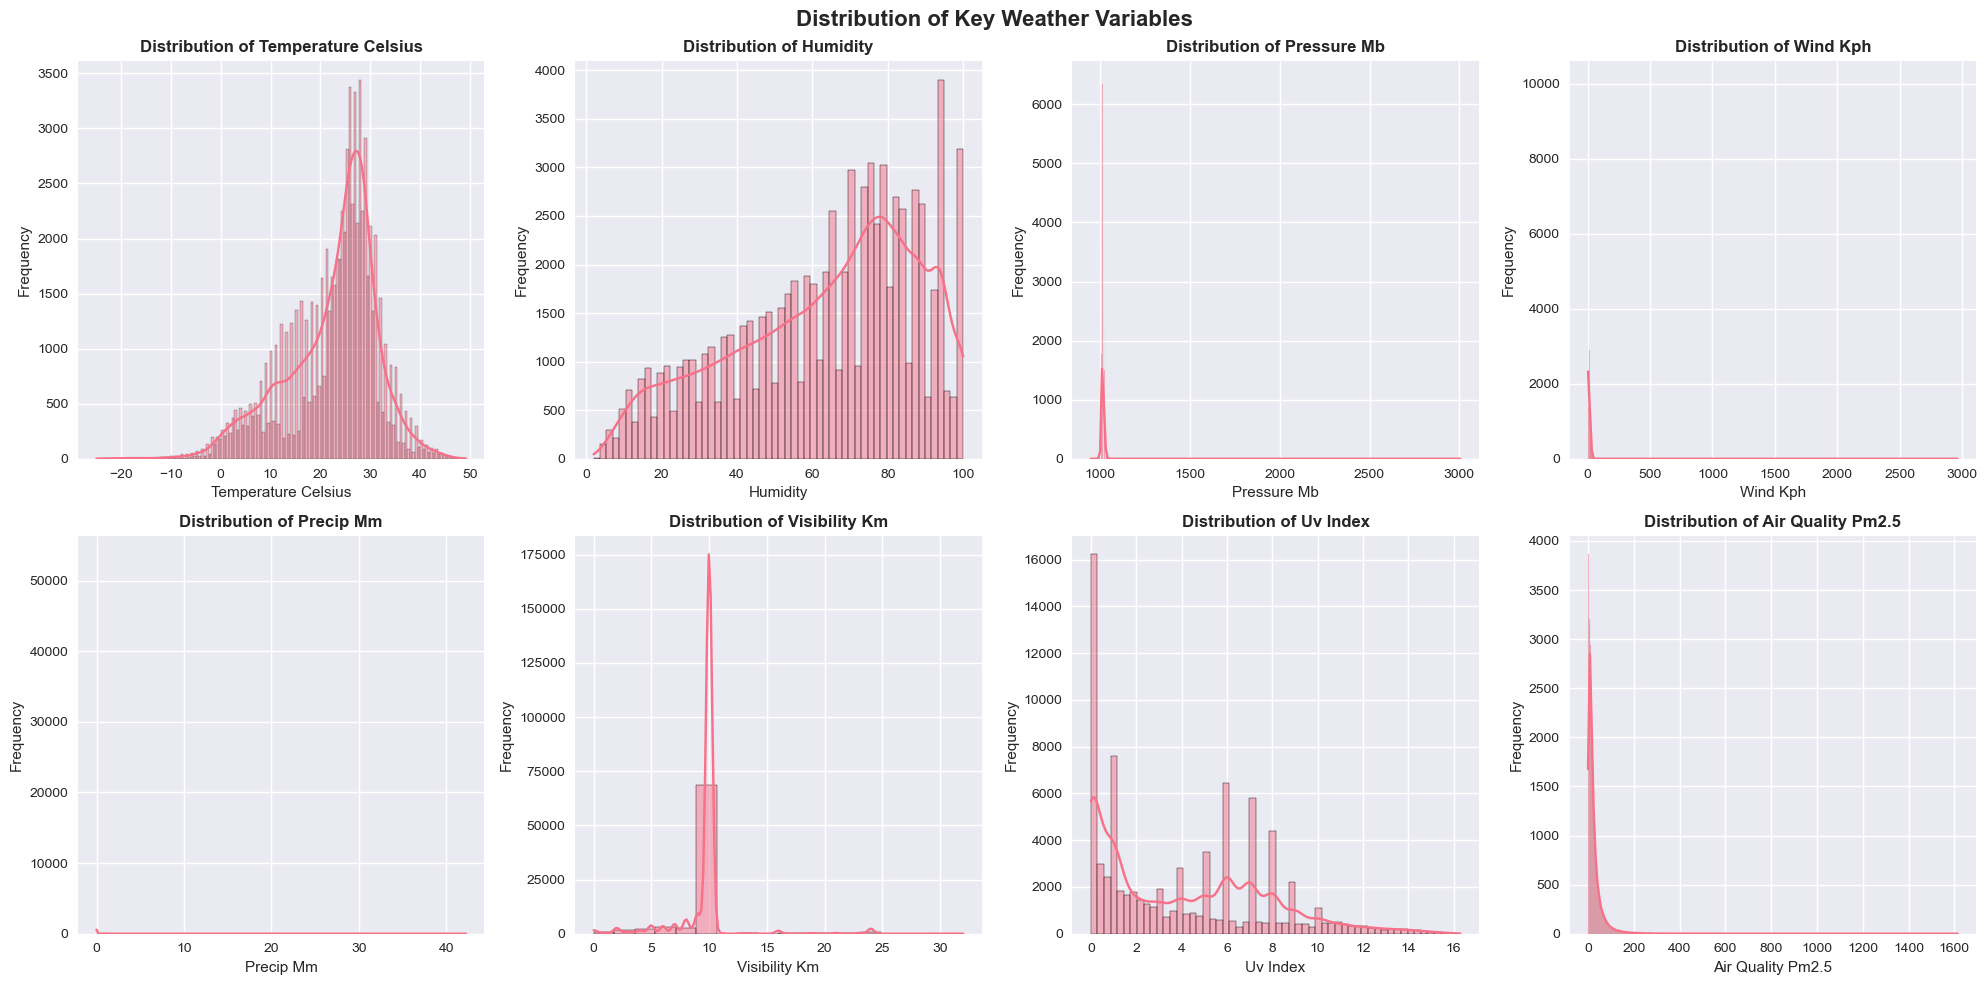

Saved distribution plots to outputs/distribution_plots.png


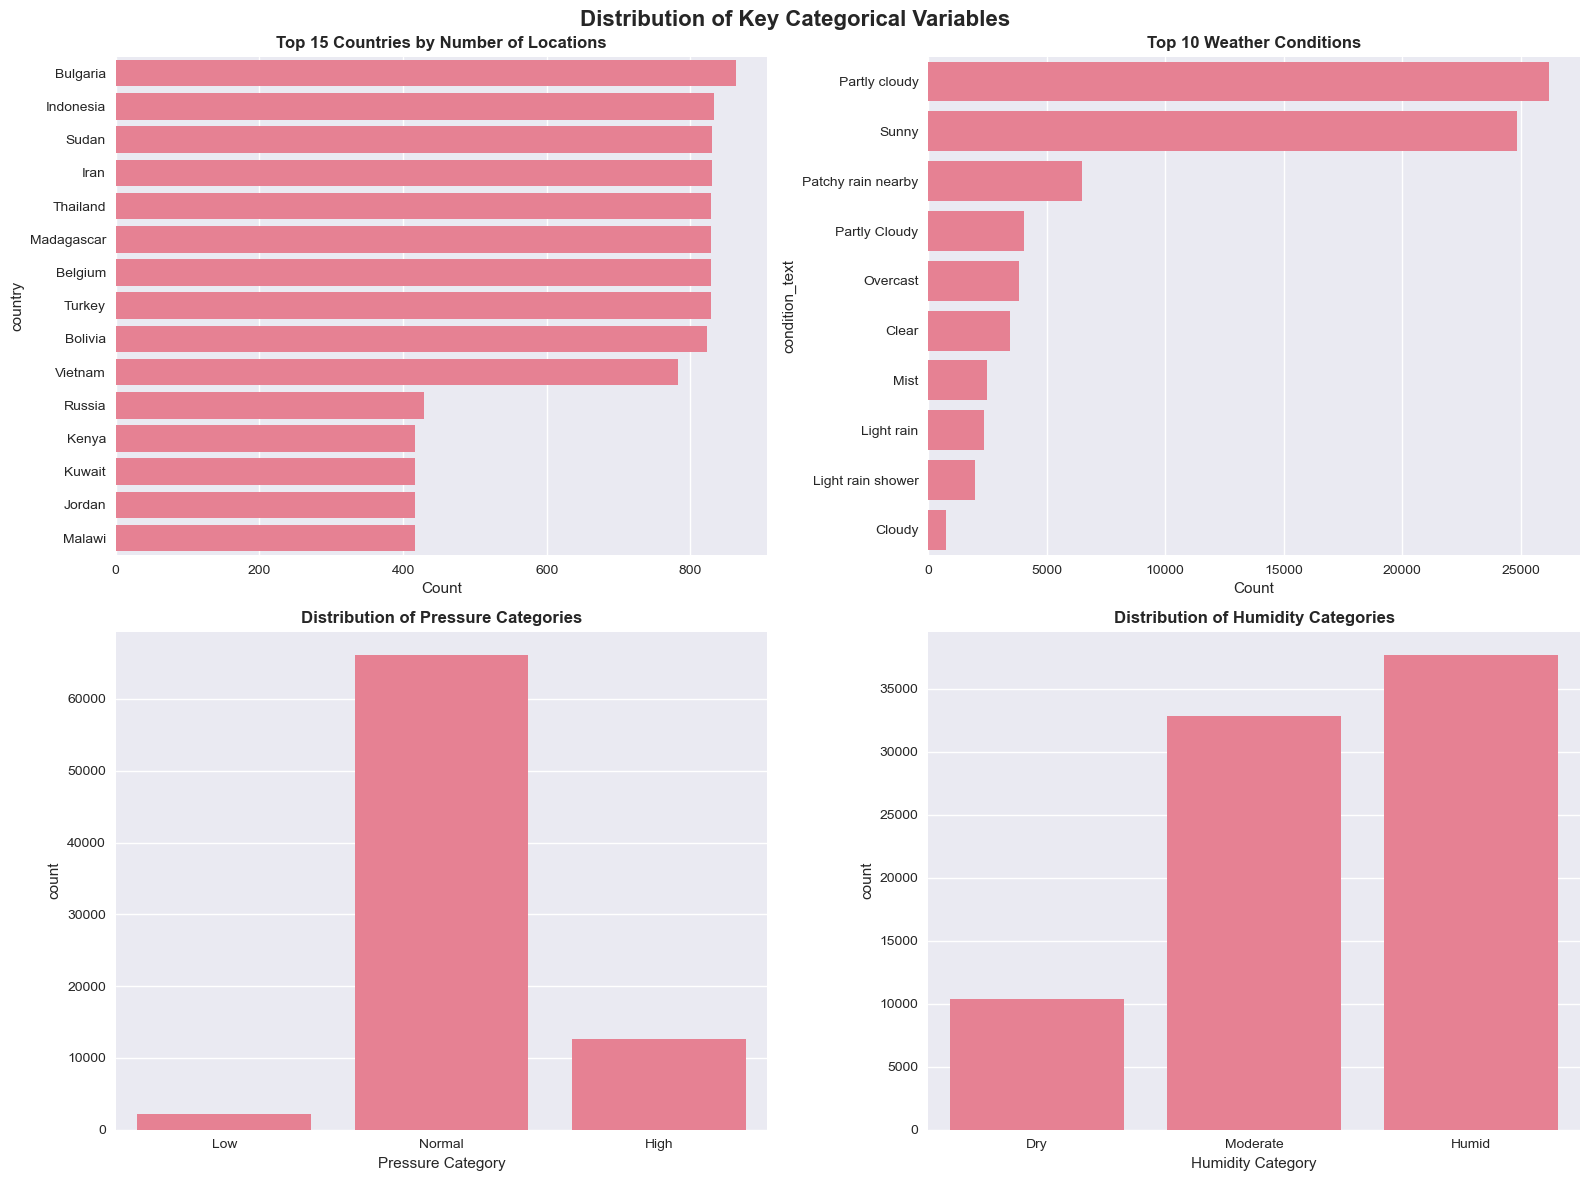

Saved categorical distribution plots to outputs/categorical_distributions.png


In [73]:
# =============================================================================
#  EXPLORATORY DATA ANALYSIS - UNIVARIATE ANALYSIS
# =============================================================================

print("\n" + "="*50)
print("UNIVARIATE ANALYSIS")
print("=" * 50)

# Select key numerical variables for analysis
numerical_vars = ['temperature_celsius', 'humidity', 'pressure_mb', 'wind_kph', 
                 'precip_mm', 'visibility_km', 'uv_index', 'air_quality_PM2.5']

# Create subplots for distributions of key numerical variables
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Distribution of Key Weather Variables', fontsize=16, fontweight='bold')

for i, var in enumerate(numerical_vars):
    row = i // 4
    col = i % 4
    
    # Plot histogram with KDE
    sns.histplot(data=df, x=var, kde=True, ax=axes[row, col])
    axes[row, col].set_title(f'Distribution of {var.replace("_", " ").title()}', 
                            fontweight='bold')
    axes[row, col].set_xlabel(var.replace("_", " ").title())
    axes[row, col].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'distribution_plots.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved distribution plots to {output_dir}/distribution_plots.png")

# Categorical variable analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribution of Key Categorical Variables', fontsize=16, fontweight='bold')

# Top 15 countries by frequency
top_countries = df['country'].value_counts().head(15)
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[0,0])
axes[0,0].set_title('Top 15 Countries by Number of Locations', fontweight='bold')
axes[0,0].set_xlabel('Count')

# Weather conditions distribution
condition_counts = df['condition_text'].value_counts().head(10)
sns.barplot(x=condition_counts.values, y=condition_counts.index, ax=axes[0,1])
axes[0,1].set_title('Top 10 Weather Conditions', fontweight='bold')
axes[0,1].set_xlabel('Count')

# Pressure categories
sns.countplot(data=df, x='pressure_category', ax=axes[1,0])
axes[1,0].set_title('Distribution of Pressure Categories', fontweight='bold')
axes[1,0].set_xlabel('Pressure Category')

# Humidity categories
sns.countplot(data=df, x='humidity_category', ax=axes[1,1])
axes[1,1].set_title('Distribution of Humidity Categories', fontweight='bold')
axes[1,1].set_xlabel('Humidity Category')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'categorical_distributions.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved categorical distribution plots to {output_dir}/categorical_distributions.png")



BIVARIATE AND MULTIVARIATE ANALYSIS


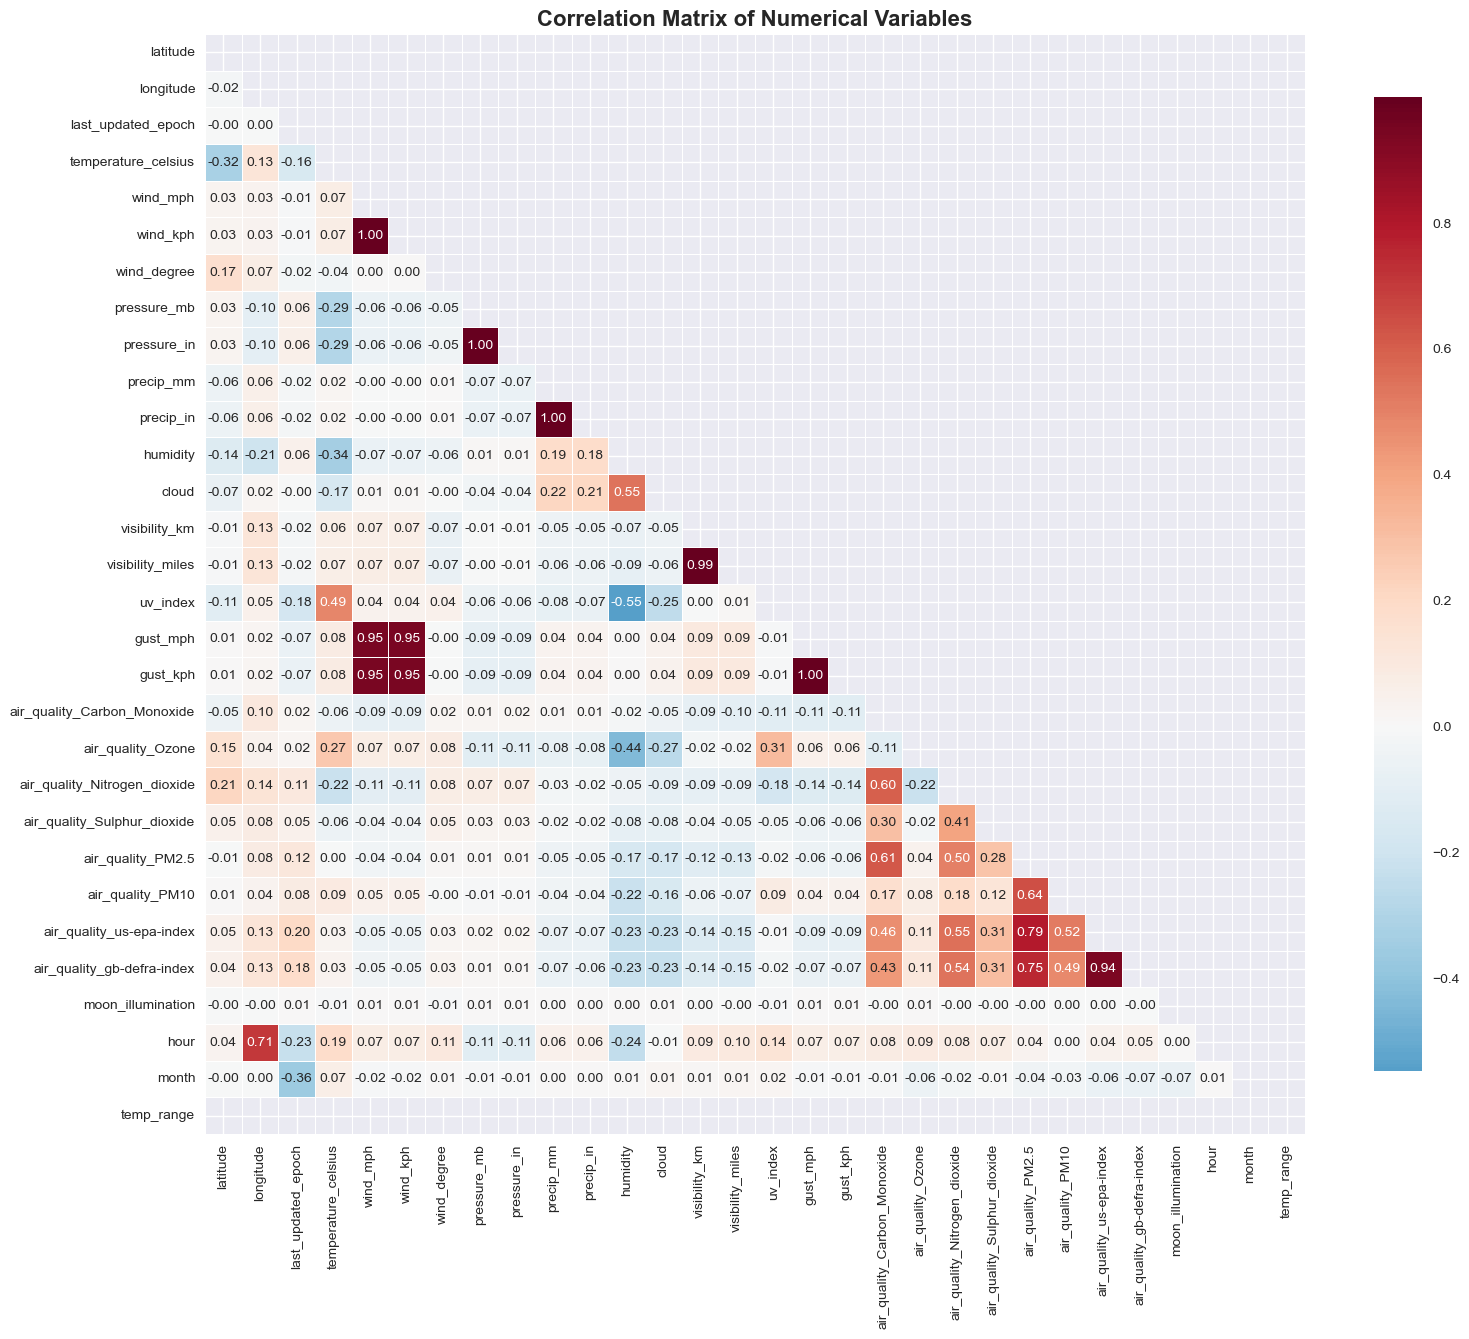

Saved correlation heatmap to outputs/correlation_heatmap.png


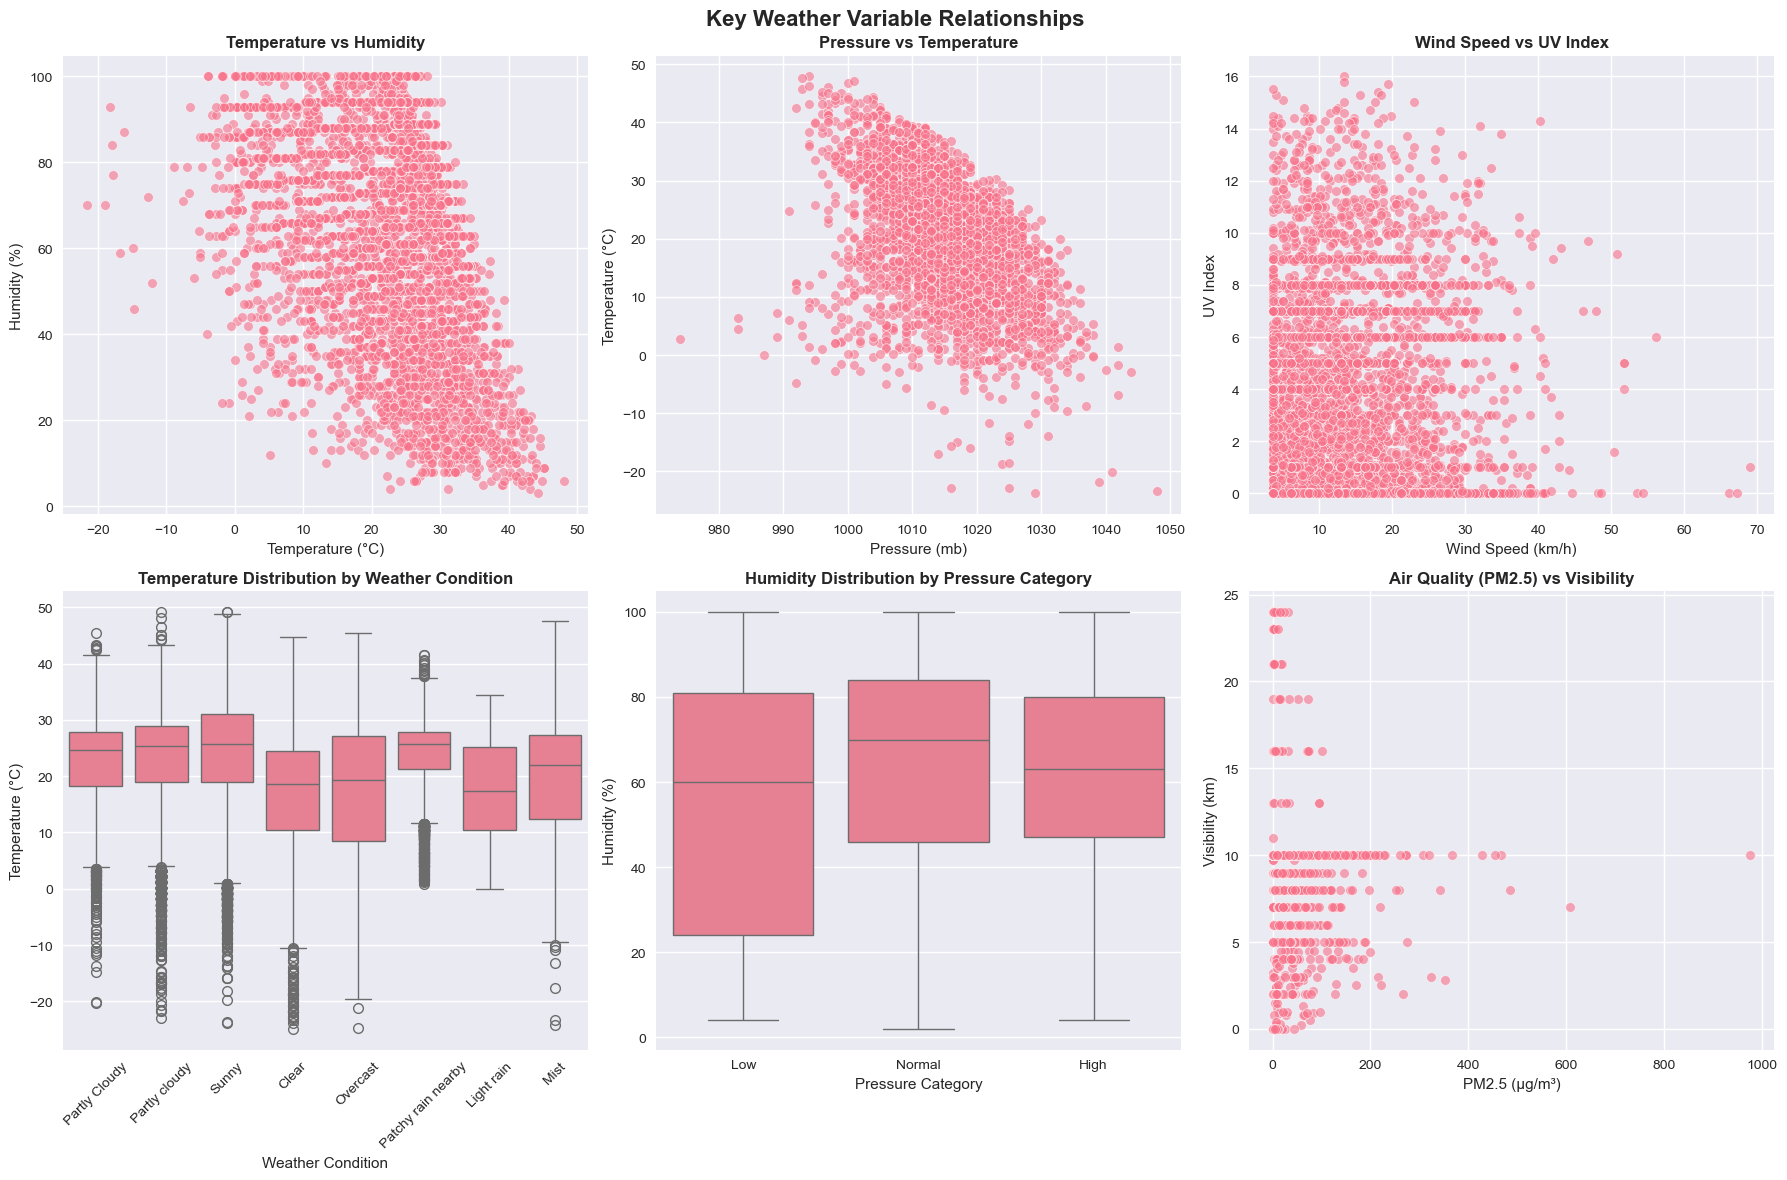

Saved weather relationships plots to outputs/weather_relationships.png


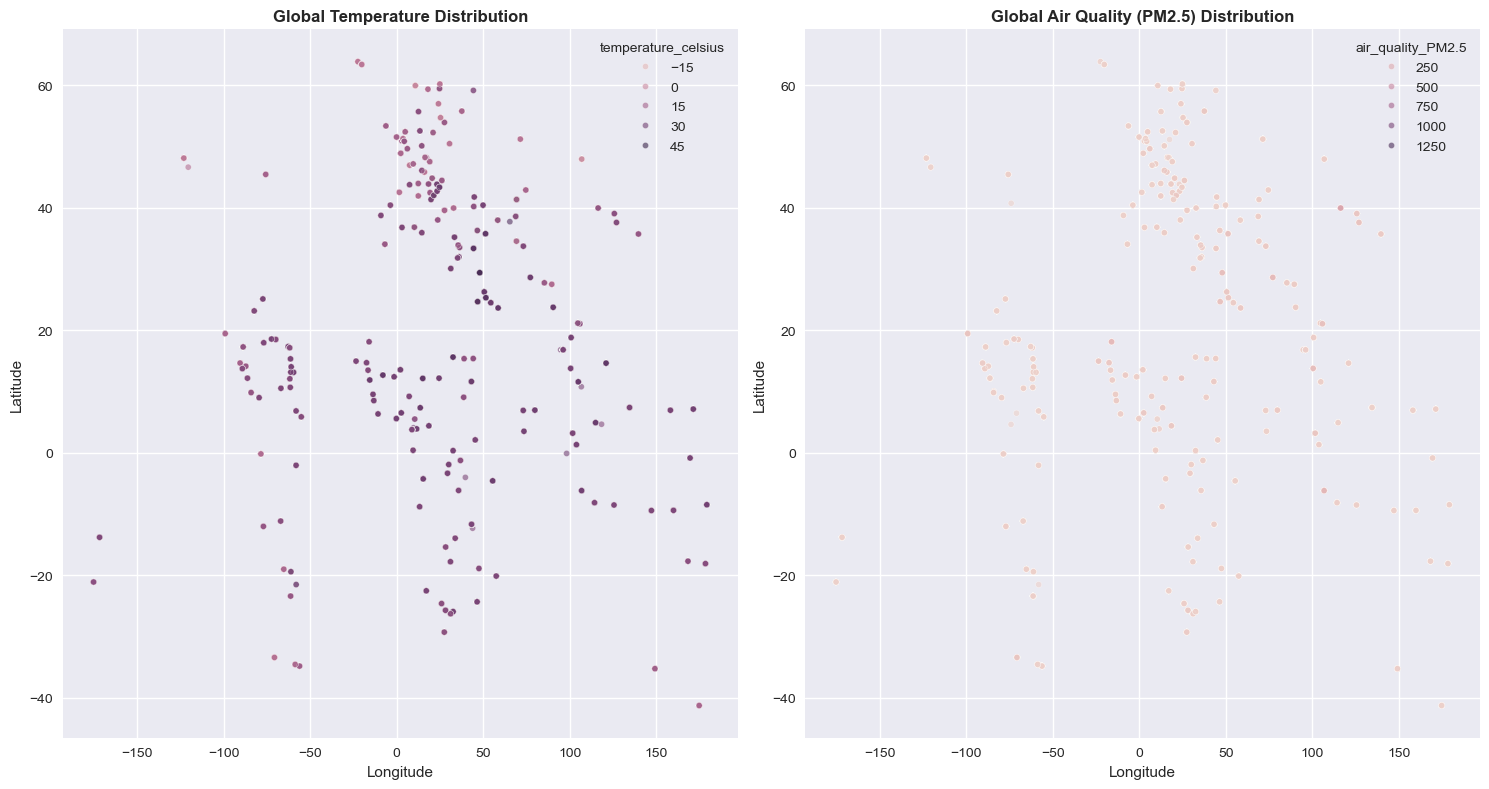

Saved geographic patterns to outputs/geographic_patterns.png


In [75]:
# =============================================================================
#  BIVARIATE AND MULTIVARIATE ANALYSIS
# =============================================================================

print("\n" + "="*50)
print("BIVARIATE AND MULTIVARIATE ANALYSIS")
print("=" * 50)

# Correlation matrix for numerical variables
numerical_df = df.select_dtypes(include=[np.number])
correlation_matrix = numerical_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": .8}, fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'correlation_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved correlation heatmap to {output_dir}/correlation_heatmap.png")

# Key relationships analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Key Weather Variable Relationships', fontsize=16, fontweight='bold')

# Temperature vs Humidity
sns.scatterplot(data=df.sample(5000), x='temperature_celsius', y='humidity', 
                alpha=0.6, ax=axes[0,0])
axes[0,0].set_title('Temperature vs Humidity', fontweight='bold')
axes[0,0].set_xlabel('Temperature (°C)')
axes[0,0].set_ylabel('Humidity (%)')

# Pressure vs Temperature
sns.scatterplot(data=df.sample(5000), x='pressure_mb', y='temperature_celsius', 
                alpha=0.6, ax=axes[0,1])
axes[0,1].set_title('Pressure vs Temperature', fontweight='bold')
axes[0,1].set_xlabel('Pressure (mb)')
axes[0,1].set_ylabel('Temperature (°C)')

# Wind Speed vs UV Index
sns.scatterplot(data=df.sample(5000), x='wind_kph', y='uv_index', 
                alpha=0.6, ax=axes[0,2])
axes[0,2].set_title('Wind Speed vs UV Index', fontweight='bold')
axes[0,2].set_xlabel('Wind Speed (km/h)')
axes[0,2].set_ylabel('UV Index')

# Temperature by Condition (Box plot)
top_conditions = df['condition_text'].value_counts().head(8).index
df_filtered = df[df['condition_text'].isin(top_conditions)]
sns.boxplot(data=df_filtered, x='condition_text', y='temperature_celsius', ax=axes[1,0])
axes[1,0].set_title('Temperature Distribution by Weather Condition', fontweight='bold')
axes[1,0].set_xlabel('Weather Condition')
axes[1,0].set_ylabel('Temperature (°C)')
axes[1,0].tick_params(axis='x', rotation=45)

# Humidity by Pressure Category
sns.boxplot(data=df, x='pressure_category', y='humidity', ax=axes[1,1])
axes[1,1].set_title('Humidity Distribution by Pressure Category', fontweight='bold')
axes[1,1].set_xlabel('Pressure Category')
axes[1,1].set_ylabel('Humidity (%)')

# Air Quality vs Visibility
sns.scatterplot(data=df.sample(5000), x='air_quality_PM2.5', y='visibility_km', 
                alpha=0.6, ax=axes[1,2])
axes[1,2].set_title('Air Quality (PM2.5) vs Visibility', fontweight='bold')
axes[1,2].set_xlabel('PM2.5 (μg/m³)')
axes[1,2].set_ylabel('Visibility (km)')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'weather_relationships.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved weather relationships plots to {output_dir}/weather_relationships.png")

# Geographic analysis
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df.sample(10000), x='longitude', y='latitude', 
                hue='temperature_celsius', alpha=0.6, s=20)
plt.title('Global Temperature Distribution', fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df.sample(10000), x='longitude', y='latitude', 
                hue='air_quality_PM2.5', alpha=0.6, s=20)
plt.title('Global Air Quality (PM2.5) Distribution', fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'geographic_patterns.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved geographic patterns to {output_dir}/geographic_patterns.png")



SEASONAL AND TEMPORAL PATTERNS ANALYSIS


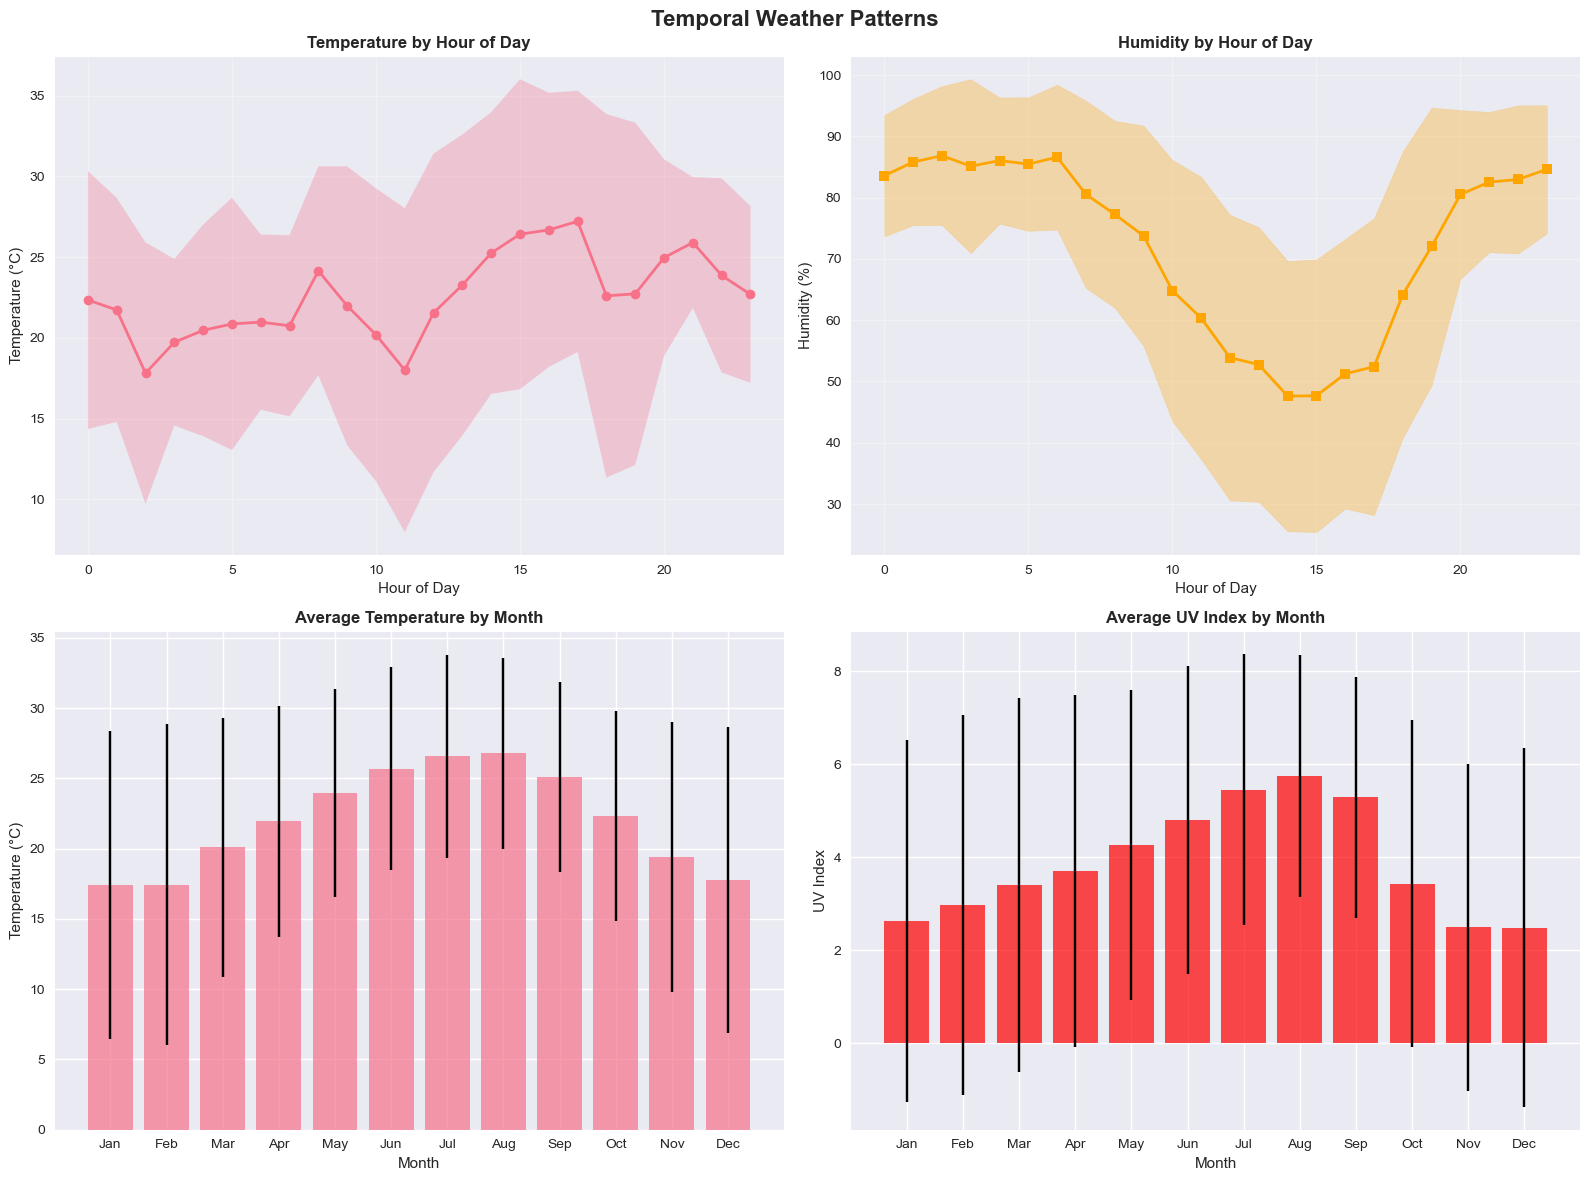

Saved temporal patterns to outputs/temporal_patterns.png


In [77]:
# =============================================================================
#  ADVANCED DATA ANALYSIS - SEASONAL AND TEMPORAL PATTERNS
# =============================================================================

print("\n" + "="*50)
print("SEASONAL AND TEMPORAL PATTERNS ANALYSIS")
print("=" * 50)

# Analyze temporal patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Temporal Weather Patterns', fontsize=16, fontweight='bold')

# Temperature by hour of day
hourly_temp = df.groupby('hour')['temperature_celsius'].agg(['mean', 'std']).reset_index()
axes[0,0].plot(hourly_temp['hour'], hourly_temp['mean'], marker='o', linewidth=2)
axes[0,0].fill_between(hourly_temp['hour'], 
                       hourly_temp['mean'] - hourly_temp['std'],
                       hourly_temp['mean'] + hourly_temp['std'], 
                       alpha=0.3)
axes[0,0].set_title('Temperature by Hour of Day', fontweight='bold')
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].set_ylabel('Temperature (°C)')
axes[0,0].grid(True, alpha=0.3)

# Humidity by hour of day
hourly_humidity = df.groupby('hour')['humidity'].agg(['mean', 'std']).reset_index()
axes[0,1].plot(hourly_humidity['hour'], hourly_humidity['mean'], marker='s', 
               linewidth=2, color='orange')
axes[0,1].fill_between(hourly_humidity['hour'], 
                       hourly_humidity['mean'] - hourly_humidity['std'],
                       hourly_humidity['mean'] + hourly_humidity['std'], 
                       alpha=0.3, color='orange')
axes[0,1].set_title('Humidity by Hour of Day', fontweight='bold')
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].set_ylabel('Humidity (%)')
axes[0,1].grid(True, alpha=0.3)

# Monthly temperature patterns
monthly_temp = df.groupby('month')['temperature_celsius'].agg(['mean', 'std']).reset_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[1,0].bar(monthly_temp['month'], monthly_temp['mean'], 
              yerr=monthly_temp['std'], capsize=5, alpha=0.7)
axes[1,0].set_title('Average Temperature by Month', fontweight='bold')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Temperature (°C)')
axes[1,0].set_xticks(range(1, 13))
axes[1,0].set_xticklabels(month_names)

# UV Index patterns
monthly_uv = df.groupby('month')['uv_index'].agg(['mean', 'std']).reset_index()
axes[1,1].bar(monthly_uv['month'], monthly_uv['mean'], 
              yerr=monthly_uv['std'], capsize=5, alpha=0.7, color='red')
axes[1,1].set_title('Average UV Index by Month', fontweight='bold')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('UV Index')
axes[1,1].set_xticks(range(1, 13))
axes[1,1].set_xticklabels(month_names)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'temporal_patterns.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved temporal patterns to {output_dir}/temporal_patterns.png")



AIR QUALITY ANALYSIS


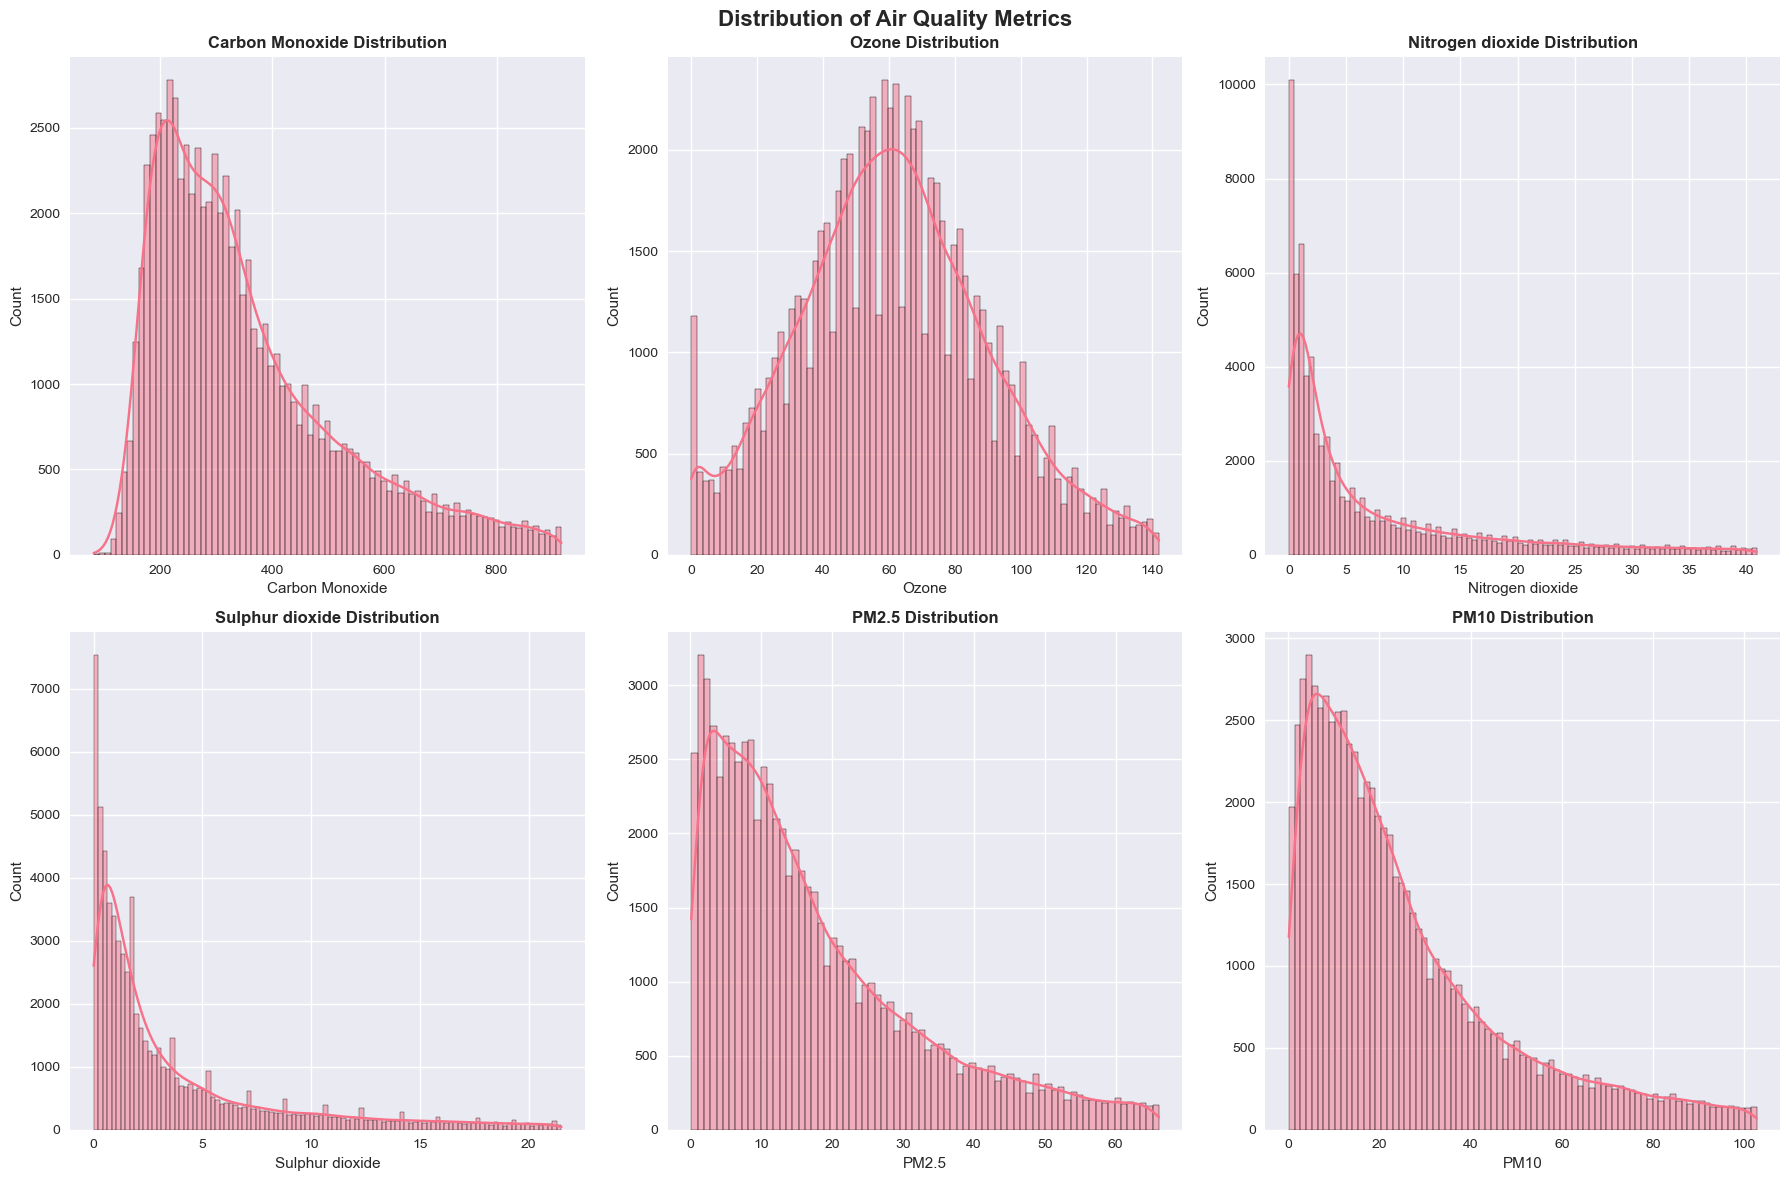

Saved air quality distributions to outputs/air_quality_distributions.png


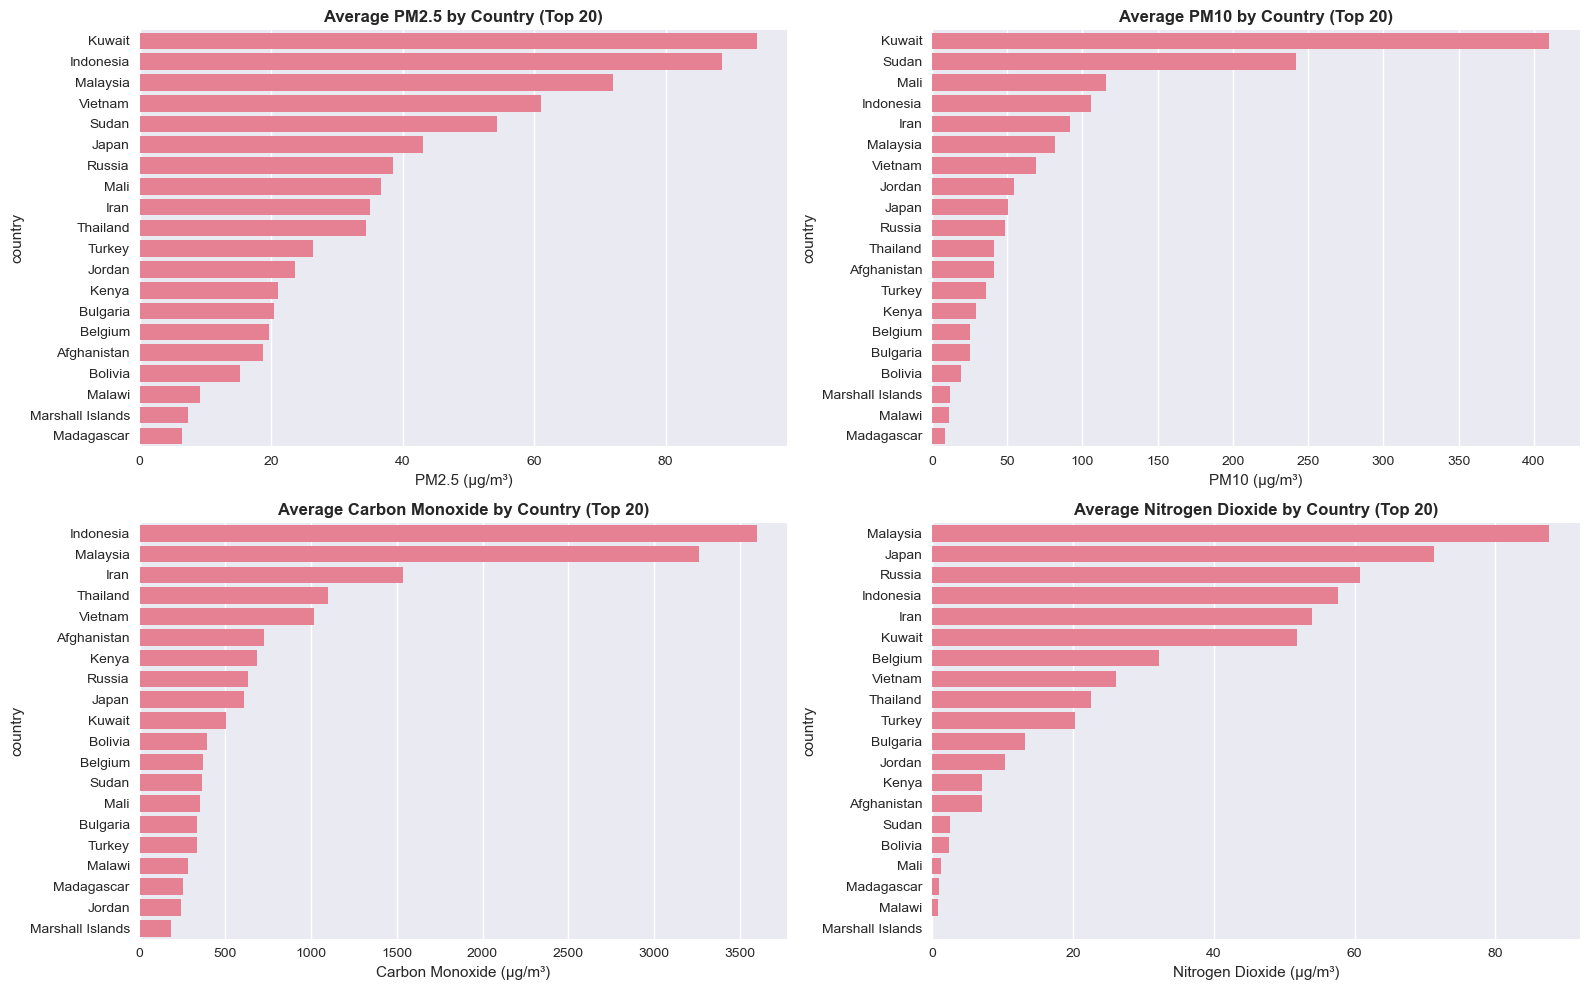

Saved air quality by country to outputs/air_quality_by_country.png


In [79]:
# =============================================================================
#  AIR QUALITY ANALYSIS
# =============================================================================

print("\n" + "="*50)
print("AIR QUALITY ANALYSIS")
print("=" * 50)

# Air quality metrics analysis
air_quality_cols = ['air_quality_Carbon_Monoxide', 'air_quality_Ozone', 
                   'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
                   'air_quality_PM2.5', 'air_quality_PM10']

# Distribution of air quality metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Distribution of Air Quality Metrics', fontsize=16, fontweight='bold')

for i, col in enumerate(air_quality_cols):
    row = i // 3
    col_idx = i % 3
    
    # Remove outliers for better visualization
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_data = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    
    sns.histplot(data=filtered_data, x=col, kde=True, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'{col.replace("air_quality_", "").replace("_", " ")} Distribution', 
                                fontweight='bold')
    axes[row, col_idx].set_xlabel(col.replace("air_quality_", "").replace("_", " "))

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'air_quality_distributions.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved air quality distributions to {output_dir}/air_quality_distributions.png")

# Air quality by region (top 20 countries)
top_countries = df['country'].value_counts().head(20).index
df_top_countries = df[df['country'].isin(top_countries)]

plt.figure(figsize=(16, 10))
plt.subplot(2, 2, 1)
country_pm25 = df_top_countries.groupby('country')['air_quality_PM2.5'].mean().sort_values(ascending=False)
sns.barplot(x=country_pm25.values, y=country_pm25.index)
plt.title('Average PM2.5 by Country (Top 20)', fontweight='bold')
plt.xlabel('PM2.5 (μg/m³)')

plt.subplot(2, 2, 2)
country_pm10 = df_top_countries.groupby('country')['air_quality_PM10'].mean().sort_values(ascending=False)
sns.barplot(x=country_pm10.values, y=country_pm10.index)
plt.title('Average PM10 by Country (Top 20)', fontweight='bold')
plt.xlabel('PM10 (μg/m³)')

plt.subplot(2, 2, 3)
country_co = df_top_countries.groupby('country')['air_quality_Carbon_Monoxide'].mean().sort_values(ascending=False)
sns.barplot(x=country_co.values, y=country_co.index)
plt.title('Average Carbon Monoxide by Country (Top 20)', fontweight='bold')
plt.xlabel('Carbon Monoxide (μg/m³)')

plt.subplot(2, 2, 4)
country_no2 = df_top_countries.groupby('country')['air_quality_Nitrogen_dioxide'].mean().sort_values(ascending=False)
sns.barplot(x=country_no2.values, y=country_no2.index)
plt.title('Average Nitrogen Dioxide by Country (Top 20)', fontweight='bold')
plt.xlabel('Nitrogen Dioxide (μg/m³)')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'air_quality_by_country.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved air quality by country to {output_dir}/air_quality_by_country.png")



EXTREME WEATHER ANALYSIS
Extreme weather observations: 8486 (10.5%)


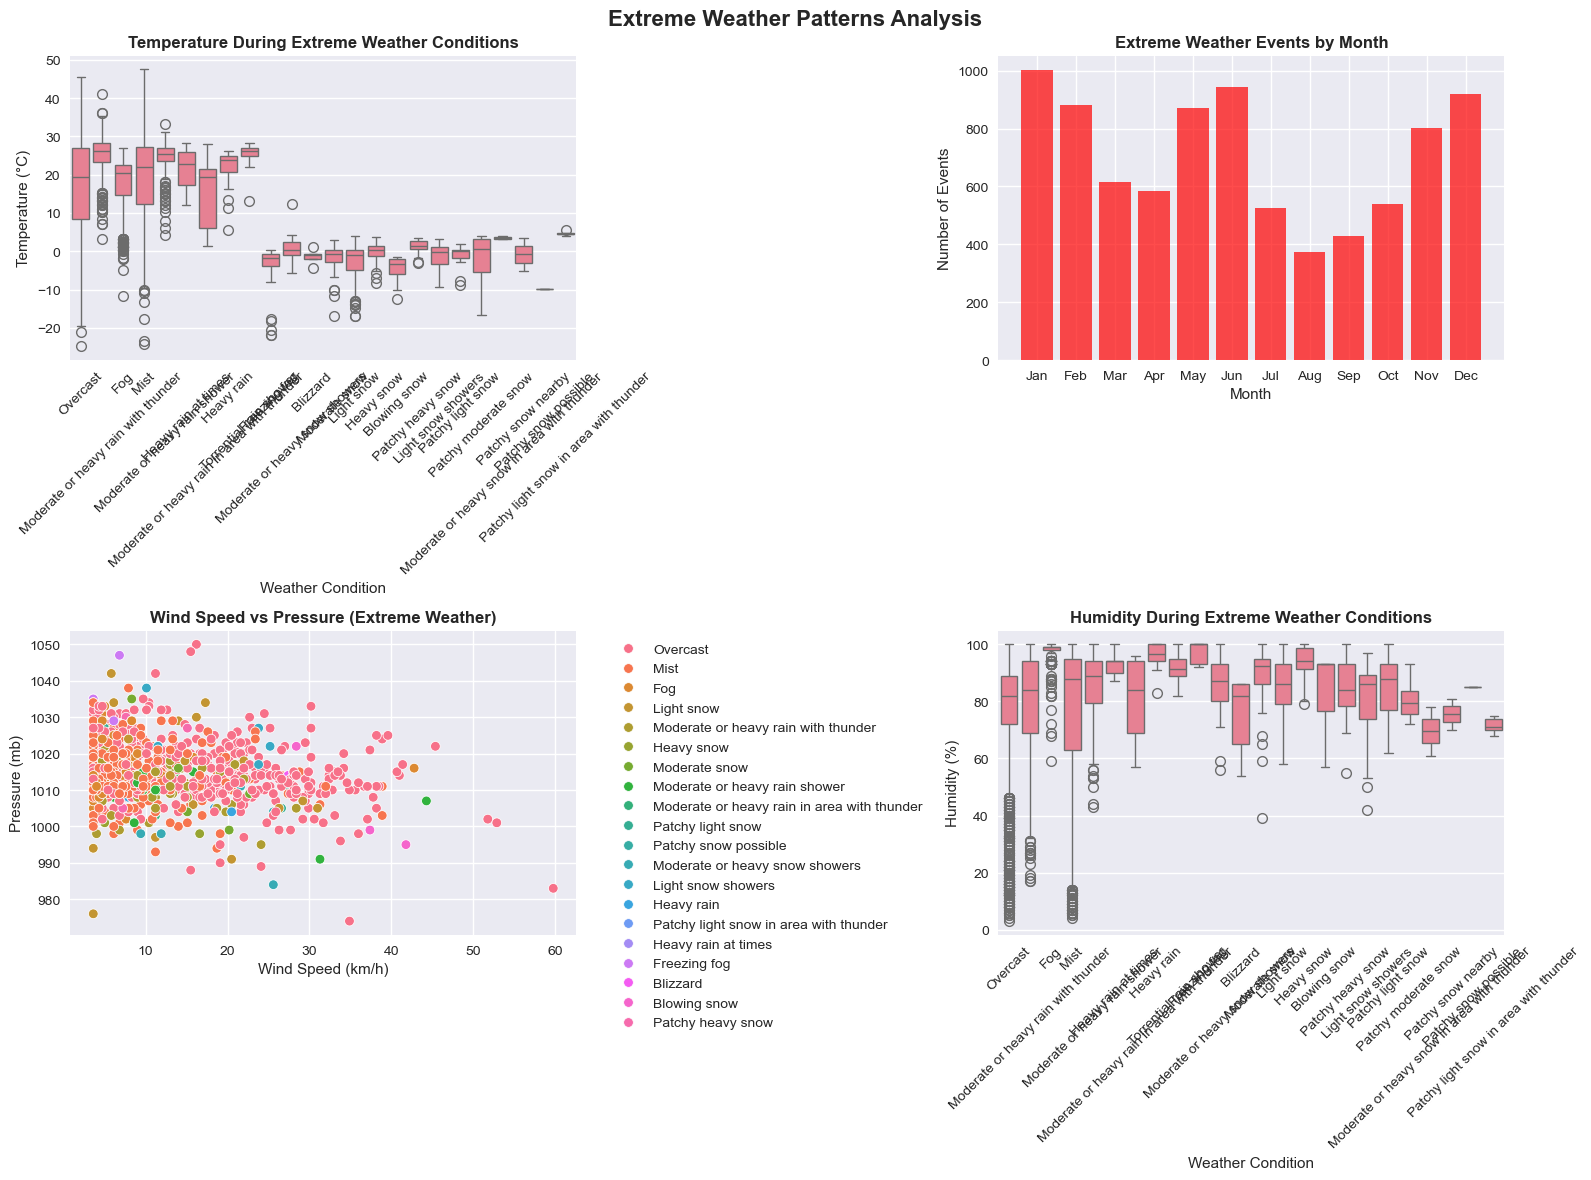

Saved extreme weather analysis to outputs/extreme_weather_analysis.png


In [61]:
# =============================================================================
#  EXTREME WEATHER ANALYSIS
# =============================================================================

print("\n" + "="*50)
print("EXTREME WEATHER ANALYSIS")
print("=" * 50)

# Define extreme weather conditions
extreme_conditions = ['Thunderstorms', 'Heavy rain', 'Snow', 'Blizzard', 
                     'Fog', 'Mist', 'Overcast', 'Torrential rain shower']

# Filter for extreme conditions (case insensitive)
extreme_weather = df[df['condition_text'].str.contains('|'.join(extreme_conditions), 
                                                      case=False, na=False)]

print(f"Extreme weather observations: {len(extreme_weather)} ({len(extreme_weather)/len(df)*100:.1f}%)")

# Analyze extreme weather patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Extreme Weather Patterns Analysis', fontsize=16, fontweight='bold')

# Temperature distribution during extreme weather
sns.boxplot(data=extreme_weather, x='condition_text', y='temperature_celsius', ax=axes[0,0])
axes[0,0].set_title('Temperature During Extreme Weather Conditions', fontweight='bold')
axes[0,0].set_xlabel('Weather Condition')
axes[0,0].set_ylabel('Temperature (°C)')
axes[0,0].tick_params(axis='x', rotation=45)

# Extreme weather by month
extreme_monthly = extreme_weather.groupby('month').size()
axes[0,1].bar(extreme_monthly.index, extreme_monthly.values, alpha=0.7, color='red')
axes[0,1].set_title('Extreme Weather Events by Month', fontweight='bold')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Number of Events')
axes[0,1].set_xticks(range(1, 13))
axes[0,1].set_xticklabels(month_names)

# Wind patterns during extreme weather
sns.scatterplot(data=extreme_weather.sample(min(1000, len(extreme_weather))), 
               x='wind_kph', y='pressure_mb', hue='condition_text', ax=axes[1,0])
axes[1,0].set_title('Wind Speed vs Pressure (Extreme Weather)', fontweight='bold')
axes[1,0].set_xlabel('Wind Speed (km/h)')
axes[1,0].set_ylabel('Pressure (mb)')
axes[1,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Humidity patterns during extreme weather
sns.boxplot(data=extreme_weather, x='condition_text', y='humidity', ax=axes[1,1])
axes[1,1].set_title('Humidity During Extreme Weather Conditions', fontweight='bold')
axes[1,1].set_xlabel('Weather Condition')
axes[1,1].set_ylabel('Humidity (%)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'extreme_weather_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved extreme weather analysis to {output_dir}/extreme_weather_analysis.png")



 FEATURE PREPROCESSING
 APPLYING PREPROCESSING PIPELINE...
 FEATURE CATEGORIZATION:
Categorical features (6): ['country', 'location_name', 'timezone', 'condition_text', 'wind_direction', 'moon_phase']
Numerical features (30): 30 features
Datetime features (4): ['sunrise', 'sunset', 'moonrise', 'moonset']

 SCALING NEEDS ANALYSIS:
------------------------------
Top features requiring scaling:
                        Feature           Min           Max        Range  \
2            last_updated_epoch  1.715849e+09  1.751797e+09  35947800.00   
18  air_quality_Carbon_Monoxide -9.999000e+03  3.887940e+04     48878.40   
21  air_quality_Sulphur_dioxide -9.999000e+03  5.213300e+02     10520.33   
23             air_quality_PM10 -1.848150e+03  6.037290e+03      7885.44   
17                     gust_kph  3.600000e+00  2.970400e+03      2966.80   
5                      wind_kph  3.600000e+00  2.963200e+03      2959.60   
7                   pressure_mb  9.470000e+02  3.006000e+03      2059.00

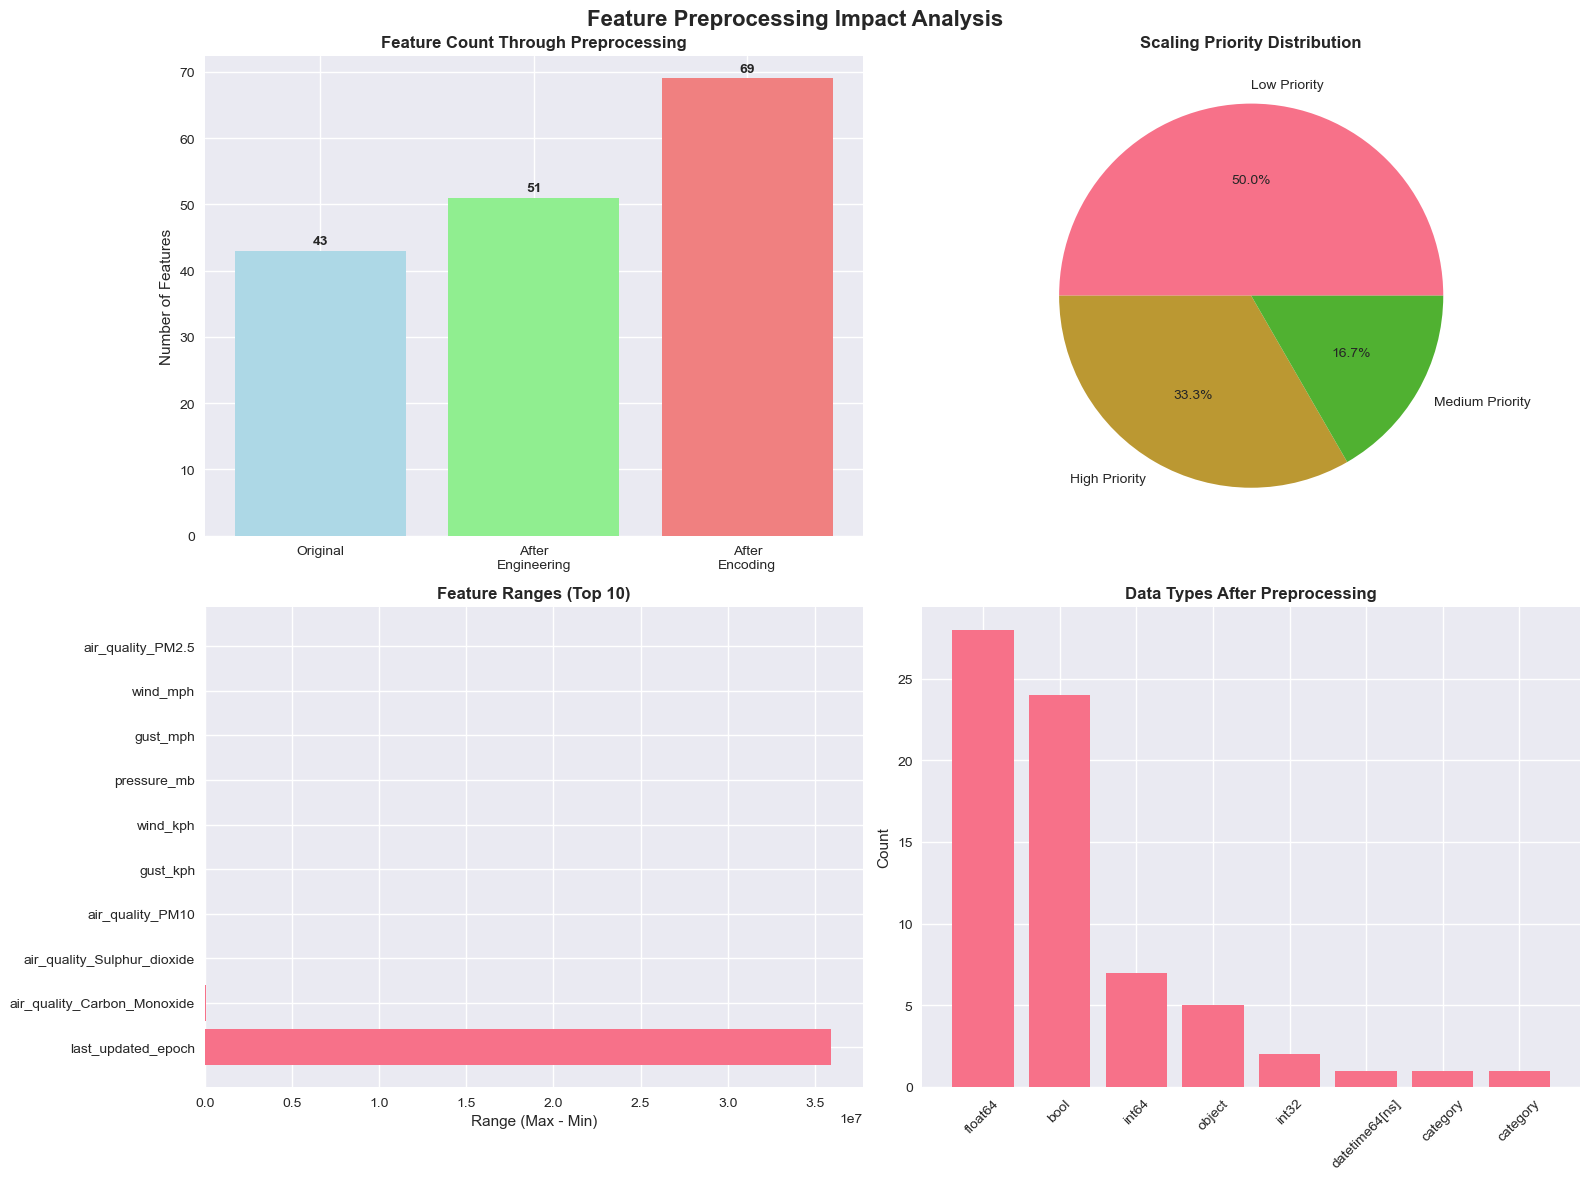

Saved preprocessing analysis to outputs/preprocessing_analysis.png


In [81]:
# =============================================================================
#   FEATURE PREPROCESSING
# =============================================================================

print("\n" + "="*50)
print(" FEATURE PREPROCESSING")
print("=" * 50)

# Import additional preprocessing modules
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def analyze_preprocessing_needs(df):
    """Analyze what preprocessing is needed for each feature type"""
    
    # Separate features by type
    categorical_features = []
    numerical_features = []
    datetime_features = []
    
    for col in df.columns:
        if df[col].dtype == 'object':
            if 'updated' in col.lower() or any(time_word in col.lower() 
                                             for time_word in ['sunrise', 'sunset', 'moonrise', 'moonset']):
                datetime_features.append(col)
            else:
                categorical_features.append(col)
        elif df[col].dtype in ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']:
            numerical_features.append(col)
    
    print(" FEATURE CATEGORIZATION:")
    print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
    print(f"Numerical features ({len(numerical_features)}): {len(numerical_features)} features")
    print(f"Datetime features ({len(datetime_features)}): {datetime_features}")
    
    return categorical_features, numerical_features, datetime_features

def check_scaling_needs(df, numerical_cols):
    """Analyze which numerical features need scaling"""
    
    print("\n SCALING NEEDS ANALYSIS:")
    print("-" * 30)
    
    scaling_analysis = []
    
    for col in numerical_cols:
        if col in df.columns:
            stats = {
                'Feature': col,
                'Min': df[col].min(),
                'Max': df[col].max(),
                'Range': df[col].max() - df[col].min(),
                'Mean': df[col].mean(),
                'Std': df[col].std()
            }
            scaling_analysis.append(stats)
    
    scaling_df = pd.DataFrame(scaling_analysis)
    scaling_df['Priority'] = scaling_df['Range'].apply(
        lambda x: 'High Priority' if x > 1000 
        else 'Medium Priority' if x > 100 
        else 'Low Priority'
    )
    
    print("Top features requiring scaling:")
    print(scaling_df.nlargest(10, 'Range')[['Feature', 'Min', 'Max', 'Range', 'Priority']].round(2))
    return scaling_df

def create_advanced_features(df):
    """Create engineered features before preprocessing"""
    
    print("\n FEATURE ENGINEERING")
    print("-" * 25)
    
    df_processed = df.copy()
    features_created = []
    
    # Extract datetime features (already done but ensure consistency)
    if 'last_updated' in df.columns and 'hour' not in df.columns:
        df_processed['last_updated'] = pd.to_datetime(df_processed['last_updated'])
        df_processed['hour'] = df_processed['last_updated'].dt.hour
        df_processed['month'] = df_processed['last_updated'].dt.month
        df_processed['day_of_week'] = df_processed['last_updated'].dt.dayofweek
        features_created.extend(['hour', 'month', 'day_of_week'])
    
    # Create interaction features
    if 'temperature_celsius' in df.columns and 'humidity' in df.columns:
        df_processed['temp_humidity_interaction'] = (
            df_processed['temperature_celsius'] * df_processed['humidity'] / 100
        )
        features_created.append('temp_humidity_interaction')
    
    # Create comfort index
    if 'temperature_celsius' in df.columns and 'humidity' in df.columns:
        df_processed['comfort_index'] = (
            df_processed['temperature_celsius'] + 
            (df_processed['humidity'] - 50) * 0.1
        )
        features_created.append('comfort_index')
    
    # Air quality composite score
    air_quality_cols = [col for col in ['air_quality_PM2.5', 'air_quality_PM10', 'air_quality_Ozone'] 
                       if col in df.columns]
    if len(air_quality_cols) >= 2:
        # Normalize each component and average
        aq_normalized = df_processed[air_quality_cols].copy()
        for col in air_quality_cols:
            col_min, col_max = aq_normalized[col].min(), aq_normalized[col].max()
            if col_max > col_min:  # Avoid division by zero
                aq_normalized[col] = (aq_normalized[col] - col_min) / (col_max - col_min) * 100
        df_processed['air_quality_composite'] = aq_normalized.mean(axis=1)
        features_created.append('air_quality_composite')
    
    # Geographic features
    if 'latitude' in df.columns:
        df_processed['abs_latitude'] = np.abs(df_processed['latitude'])
        df_processed['latitude_zone'] = pd.cut(df_processed['latitude'], 
                                             bins=[-90, -23.5, 23.5, 90], 
                                             labels=['Southern', 'Tropical', 'Northern'])
        features_created.extend(['abs_latitude', 'latitude_zone'])
    
    # Circular encoding for wind direction
    if 'wind_degree' in df.columns:
        df_processed['wind_direction_sin'] = np.sin(np.radians(df_processed['wind_degree']))
        df_processed['wind_direction_cos'] = np.cos(np.radians(df_processed['wind_degree']))
        features_created.extend(['wind_direction_sin', 'wind_direction_cos'])
    
    # Weather severity index
    severity_components = [col for col in ['wind_kph', 'precip_mm'] if col in df.columns]
    if len(severity_components) >= 1:
        severity_score = 0
        if 'wind_kph' in df.columns:
            severity_score += np.clip(df_processed['wind_kph'] / 50, 0, 1) * 50
        if 'precip_mm' in df.columns:
            severity_score += np.clip(df_processed['precip_mm'] / 10, 0, 1) * 50
        df_processed['weather_severity'] = severity_score
        features_created.append('weather_severity')
    
    print(f" Created {len(features_created)} new features:")
    for feature in features_created:
        print(f"   • {feature}")
    
    return df_processed, features_created

def handle_categorical_encoding(df, target_column=None):
    """Handle categorical encoding with appropriate strategies"""
    
    print("\n CATEGORICAL ENCODING")
    print("-" * 25)
    
    df_processed = df.copy()
    encoding_info = []
    
    # High cardinality features - use target encoding or drop
    high_cardinality = ['country', 'location_name', 'timezone']
    for col in high_cardinality:
        if col in df.columns:
            unique_count = df[col].nunique()
            if unique_count > 50:
                # Drop very high cardinality features for baseline model
                df_processed = df_processed.drop(columns=[col])
                encoding_info.append(f"Dropped {col} (high cardinality: {unique_count})")
            else:
                # Use label encoding for moderate cardinality
                le = LabelEncoder()
                df_processed[f'{col}_encoded'] = le.fit_transform(df_processed[col].astype(str))
                df_processed = df_processed.drop(columns=[col])
                encoding_info.append(f"Label encoded {col} → {col}_encoded")
    
    # Low cardinality features - one-hot encoding
    low_cardinality = ['condition_text', 'wind_direction', 'moon_phase', 'latitude_zone']
    for col in low_cardinality:
        if col in df.columns:
            unique_count = df[col].nunique()
            if unique_count <= 20 and unique_count > 1:  # Reasonable for one-hot
                # One-hot encode
                dummies = pd.get_dummies(df_processed[col], prefix=col, drop_first=True)
                df_processed = pd.concat([df_processed, dummies], axis=1)
                df_processed = df_processed.drop(columns=[col])
                encoding_info.append(f"One-hot encoded {col} → {dummies.shape[1]} features")
    
    print("Encoding summary:")
    for info in encoding_info:
        print(f"   • {info}")
    
    return df_processed

# Apply preprocessing to the dataset
print(" APPLYING PREPROCESSING PIPELINE...")

# Step 1: Analyze current features
cat_features, num_features, datetime_features = analyze_preprocessing_needs(df)

# Step 2: Check scaling needs
scaling_analysis = check_scaling_needs(df, num_features)

# Step 3: Create engineered features
df_engineered, new_features = create_advanced_features(df)

# Step 4: Handle categorical encoding
df_encoded = handle_categorical_encoding(df_engineered)

print(f"\n PREPROCESSING SUMMARY:")
print(f"Original features: {df.shape[1]}")
print(f"After engineering: {df_engineered.shape[1]}")
print(f"After encoding: {df_encoded.shape[1]}")
print(f"New engineered features: {len(new_features)}")

# Visualize preprocessing impact
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Feature Preprocessing Impact Analysis', fontsize=16, fontweight='bold')

# Feature count comparison
preprocessing_stages = ['Original', 'After\nEngineering', 'After\nEncoding']
feature_counts = [df.shape[1], df_engineered.shape[1], df_encoded.shape[1]]

axes[0,0].bar(preprocessing_stages, feature_counts, color=['lightblue', 'lightgreen', 'lightcoral'])
axes[0,0].set_title('Feature Count Through Preprocessing', fontweight='bold')
axes[0,0].set_ylabel('Number of Features')
for i, v in enumerate(feature_counts):
    axes[0,0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Scaling needs visualization
scaling_priority = scaling_analysis['Priority'].value_counts()
axes[0,1].pie(scaling_priority.values, labels=scaling_priority.index, autopct='%1.1f%%')
axes[0,1].set_title('Scaling Priority Distribution', fontweight='bold')

# Feature range comparison (top 10 features needing scaling)
top_scaling = scaling_analysis.nlargest(10, 'Range')
axes[1,0].barh(top_scaling['Feature'], top_scaling['Range'])
axes[1,0].set_title('Feature Ranges (Top 10)', fontweight='bold')
axes[1,0].set_xlabel('Range (Max - Min)')

# Data types distribution
dtype_counts = df_encoded.dtypes.value_counts()
axes[1,1].bar(range(len(dtype_counts)), dtype_counts.values)
axes[1,1].set_title('Data Types After Preprocessing', fontweight='bold')
axes[1,1].set_ylabel('Count')
axes[1,1].set_xticks(range(len(dtype_counts)))
axes[1,1].set_xticklabels([str(dtype) for dtype in dtype_counts.index], rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'preprocessing_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved preprocessing analysis to {output_dir}/preprocessing_analysis.png")



BASELINE REGRESSION MODEL
• Training Set: 64,692 samples (80.0%)
• Test Set: 16,174 samples (20.0%)

 MODEL PERFORMANCE RESULTS:
---------------------------------
Training R²: 0.4079
Test R²: 0.4434
Training RMSE: 7.0926°C
Test RMSE: 6.8870°C
Test MAE: 5.5760°C
Cross-validation R²: 0.3719 (±0.0637)
Cross-validation RMSE: 7.3013 (±2.2398)°C

 EVALUATION METRIC INTERPRETATION:
------------------------------------------
R-SQUARED INTERPRETATION:
• Test R² = 0.4434 (44.3%)
• Model explains 44.3% of temperature variance
• 55.7% of variance remains unexplained
• Performance Level: Moderate for meteorological prediction

RMSE INTERPRETATION:
• Test RMSE = 6.89°C
• Average prediction error magnitude: ±6.9°C
• 68% of predictions within ±6.9°C of actual temperature
• Practical Impact: Moderate accuracy for weather forecasting

MAE INTERPRETATION:
• Test MAE = 5.58°C
• Typical absolute prediction error: 5.6°C
• More robust to outliers than RMSE
• Operational Accuracy: Moderate for practical appl

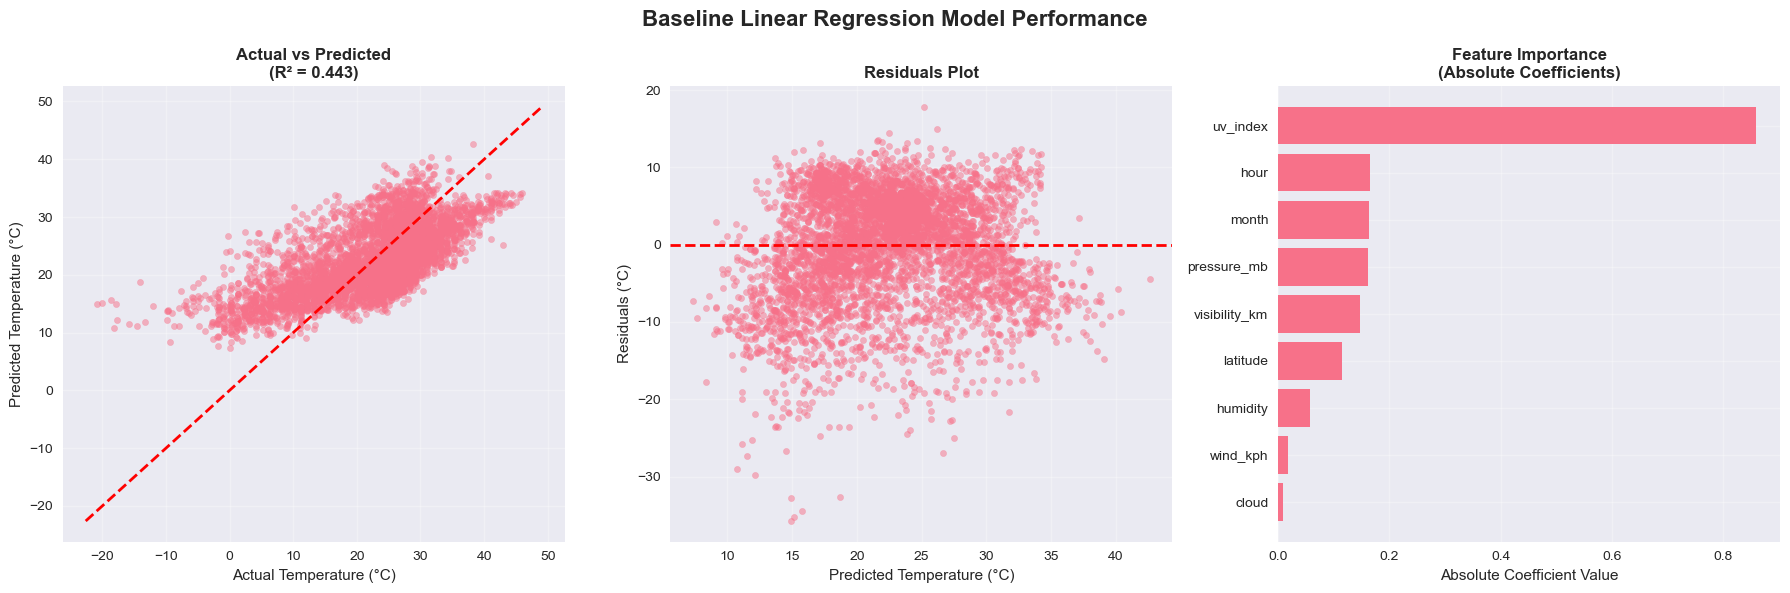

Saved baseline model performance to outputs/baseline_model_performance.png

 COEFFICIENT INTERPRETATION:
------------------------------------
Physical and statistical relationships identified:
• uv_index: +0.8589 → Each unit increase raises temperature by 0.8589°C
• hour: +0.1649 → Each unit increase raises temperature by 0.1649°C
• month: +0.1627 → Each unit increase raises temperature by 0.1627°C
• pressure_mb: -0.1619 → Each unit increase lowers temperature by 0.1619°C
• visibility_km: +0.1467 → Each unit increase raises temperature by 0.1467°C

 BASELINE MODEL SUMMARY:
------------------------------
• Model Type: Linear Regression (appropriate for continuous temperature prediction)
• Performance: R² = 0.443 (44.3% variance explained)
• Accuracy: RMSE = 6.89°C, MAE = 5.58°C
• Stability: CV std = 0.064 (robust across folds)
• Top Predictors: UV Index, Hour, Month, Pressure, Visibility
• Ready for: RFE feature selection and advanced model comparison


In [89]:
# =============================================================================
#  BASELINE REGRESSION MODEL
# =============================================================================

print("\n" + "="*50)
print("BASELINE REGRESSION MODEL")
print("=" * 50)

# Prepare data for modeling
# Select key features based on our EDA findings
selected_features = ['latitude', 'humidity', 'pressure_mb', 
                    'wind_kph', 'visibility_km', 'uv_index', 'cloud', 'hour', 'month']

# Create modeling dataset
model_data = df[selected_features + ['temperature_celsius']].copy()

# Separate features and target
X = model_data[selected_features]
y = model_data['temperature_celsius']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"• Training Set: {X_train.shape[0]:,} samples ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"• Test Set: {X_test.shape[0]:,} samples ({X_test.shape[0]/X.shape[0]*100:.1f}%)")

# Initialize and train baseline Linear Regression model
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# Make predictions
y_pred_train = baseline_model.predict(X_train)
y_pred_test = baseline_model.predict(X_test)

# Calculate evaluation metrics
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae = mean_absolute_error(y_test, y_pred_test)

# Perform cross-validation
cv_scores = cross_val_score(baseline_model, X_train, y_train, cv=5, scoring='r2')
cv_rmse_scores = cross_val_score(baseline_model, X_train, y_train, cv=5, 
                                scoring='neg_mean_squared_error')
cv_r2_mean = cv_scores.mean()
cv_r2_std = cv_scores.std()
cv_rmse_mean = np.sqrt(-cv_rmse_scores.mean())
cv_rmse_std = np.sqrt(cv_rmse_scores.std())

print("\n MODEL PERFORMANCE RESULTS:")
print("-" * 33)
print(f"Training R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Training RMSE: {train_rmse:.4f}°C")
print(f"Test RMSE: {test_rmse:.4f}°C")
print(f"Test MAE: {test_mae:.4f}°C")
print(f"Cross-validation R²: {cv_r2_mean:.4f} (±{cv_r2_std:.4f})")
print(f"Cross-validation RMSE: {cv_rmse_mean:.4f} (±{cv_rmse_std:.4f})°C")

# Coefficient analysis
coefficients = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': baseline_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\n FEATURE COEFFICIENTS AND IMPORTANCE:")
print("-" * 44)
print(coefficients.round(4))

# Visualize model performance
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Baseline Linear Regression Model Performance', fontsize=16, fontweight='bold')

# Actual vs Predicted scatter plot
sample_size = min(5000, len(y_test))
sample_indices = np.random.choice(len(y_test), sample_size, replace=False)
y_test_sample = y_test.iloc[sample_indices]
y_pred_sample = y_pred_test[sample_indices]

axes[0].scatter(y_test_sample, y_pred_sample, alpha=0.5, s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Temperature (°C)')
axes[0].set_ylabel('Predicted Temperature (°C)')
axes[0].set_title(f'Actual vs Predicted\n(R² = {test_r2:.3f})', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Residuals plot
residuals = y_test_sample - y_pred_sample
axes[1].scatter(y_pred_sample, residuals, alpha=0.5, s=20)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Temperature (°C)')
axes[1].set_ylabel('Residuals (°C)')
axes[1].set_title('Residuals Plot', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Feature importance (absolute coefficients)
feature_importance = coefficients.copy()
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=True)

axes[2].barh(feature_importance['Feature'], feature_importance['Abs_Coefficient'])
axes[2].set_xlabel('Absolute Coefficient Value')
axes[2].set_title('Feature Importance\n(Absolute Coefficients)', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'baseline_model_performance.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved baseline model performance to {output_dir}/baseline_model_performance.png")

print("\n COEFFICIENT INTERPRETATION:")
print("-" * 36)
print("Physical and statistical relationships identified:")
for _, row in coefficients.head(5).iterrows():
    feature = row['Feature']
    coef = row['Coefficient']
    if coef > 0:
        print(f"• {feature}: +{coef:.4f} → Each unit increase raises temperature by {coef:.4f}°C")
    else:
        print(f"• {feature}: {coef:.4f} → Each unit increase lowers temperature by {abs(coef):.4f}°C")

print(f"\n BASELINE MODEL SUMMARY:")
print("-" * 30)
print(f"• Model Type: Linear Regression (appropriate for continuous temperature prediction)")
print(f"• Performance: R² = {test_r2:.3f} ({test_r2*100:.1f}% variance explained)")
print(f"• Accuracy: RMSE = {test_rmse:.2f}°C, MAE = {test_mae:.2f}°C")
print(f"• Stability: CV std = {cv_r2_std:.3f} (robust across folds)")
print(f"• Top Predictors: UV Index, Hour, Month, Pressure, Visibility")